#  Project Introduction: Understanding Biomakers for Chronic Kidney Disease (CKD) Prevention

## Aim:  To perform exploratory data analysis and understand how well biomakers diagnosizes CKD

## Global Context and Importance 🌍
Chronic Kidney Disease (CKD) is a critical global health challenge, estimated to affect approximately **850 million people** worldwide 🌏. It is currently the third fastest-growing cause of death globally and is projected to become the 5th highest cause of years of life lost (YLL) by 2040. 

A significant issue in managing CKD is that up to 90% of individuals in resource-poor settings are unaware of their condition until it reaches advanced stages. Early detection is vital for prevention and treatment.

## Dataset Overview 📊
This dataset contains detailed health records for **1,659 patients** diagnosed with CKD. It encompasses a wide range of variables including demographics, clinical measurements, lifestyle factors, and medical history. A synthetic dataset was used for this project. This implies that there won't be much clinical significance of the features or meaningful statistical correlation. The project was carried out for educational purpose. It was only used to test exploratory data analysis.

### Key Features and Variables 🧪
The data is structured across several key domains:
* **Demographics** 👥: Includes patient **Age** (20–90 years), **Gender**, **Ethnicity**, and **Socioeconomic Status**.
* **Lifestyle Factors** 🍏: Captures **BMI** (15–40), **Smoking** status, **Alcohol Consumption**, **Physical Activity**, and **Diet/Sleep Quality** scores.
* **Medical History** 📋: Tracks family history of kidney disease, hypertension, and diabetes, as well as personal history of **Urinary Tract Infections (UTIs)** and **Acute Kidney Injury (AKI)**.
* **Clinical Measurements** 🩸: Critical health indicators such as **Systolic and Diastolic Blood Pressure**, **Fasting Blood Sugar**, and **HbA1c**.

## Biomarkers and the Role of GFR 🧬
Biomarkers are essential measurable indicators used to assess biological processes and disease progression. 

* **Glomerular Filtration Rate (GFR)** 🔍: Recognized as the best overall index of kidney function.
* **Other Biomarkers** 🧪: Includes **Blood Urea Nitrogen (BUN)**, as well as **urine protein**.

Monitoring these biomarkers, particularly GFR, is vital for early diagnosis, especially for high-risk individuals with diabetes or hypertension. 🏥📉

## Data Importation, Cleaning, and Exploration

In [2]:
import pandas as pd # Importing the Pandas package with an alias, pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ckd_df = pd.read_csv('Chronic_Kidney_Dsease_data.csv') # Reading the CSV file into a DataFrame called ckd_df
ckd_df.head() # Displaying the first few rows of the DataFrame to get an overview of the data

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [4]:
# Getting information about the DataFrame, including data types and non-null counts
ckd_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [5]:
# summarizing the DataFrame to get statistical insights about the numerical columns
ckd_df.describe()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
count,1659.000000,1659.000000,1659.000000,1659.00000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,...,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,830.000000,54.441230,0.515371,0.71308,0.977697,1.693189,27.620049,0.292948,9.969831,5.024247,...,3.525510,5.054869,49.730659,0.044002,0.103074,0.197107,2.000336,4.947788,5.144973,0.918626
std,479.056364,20.549757,0.499914,1.00043,0.776686,0.910611,7.288670,0.455252,5.798787,2.866274,...,2.026131,2.880460,27.827593,0.205162,0.304147,0.397934,1.141635,2.869959,2.901138,0.273492
min,1.000000,20.000000,0.000000,0.00000,0.000000,0.000000,15.033888,0.000000,0.021740,0.001186,...,0.006327,0.013697,0.087256,0.000000,0.000000,0.000000,0.001082,0.005392,0.004436,0.000000
25%,415.500000,36.000000,0.000000,0.00000,0.000000,1.000000,21.471449,0.000000,5.051156,2.555038,...,1.820793,2.532867,26.991708,0.000000,0.000000,0.000000,1.005802,2.498119,2.569561,1.000000
50%,830.000000,54.000000,1.000000,0.00000,1.000000,2.000000,27.652077,0.000000,9.951503,5.072395,...,3.572522,5.087086,48.970075,0.000000,0.000000,0.000000,2.040635,4.974069,5.182949,1.000000
75%,1244.500000,72.000000,1.000000,1.00000,2.000000,2.000000,34.015849,1.000000,14.967100,7.460563,...,5.254956,7.552093,73.913997,0.000000,0.000000,0.000000,2.947213,7.499783,7.733253,1.000000
max,1659.000000,90.000000,1.000000,3.00000,2.000000,3.000000,39.993532,1.000000,19.992713,9.998167,...,6.984636,9.998313,99.987510,1.000000,1.000000,1.000000,3.999469,9.992345,9.993754,1.000000


In [6]:
# Checking for missing values in the DataFrame
ckd_df.isnull().sum()

PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
SocioeconomicStatus              0
EducationLevel                   0
BMI                              0
Smoking                          0
AlcoholConsumption               0
PhysicalActivity                 0
DietQuality                      0
SleepQuality                     0
FamilyHistoryKidneyDisease       0
FamilyHistoryHypertension        0
FamilyHistoryDiabetes            0
PreviousAcuteKidneyInjury        0
UrinaryTractInfections           0
SystolicBP                       0
DiastolicBP                      0
FastingBloodSugar                0
HbA1c                            0
SerumCreatinine                  0
BUNLevels                        0
GFR                              0
ProteinInUrine                   0
ACR                              0
SerumElectrolytesSodium          0
SerumElectrolytesPotassium       0
SerumElectrolytesCal

In [7]:
# checking for duplicates in the DataFrame
ckd_df.duplicated().sum()

np.int64(0)

In [8]:
# Drop unwanted columns from the DataFrame
ckd_df = ckd_df.drop(columns=['DoctorInCharge']) 

In [9]:
ckd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

## Exploratory Data Analysis

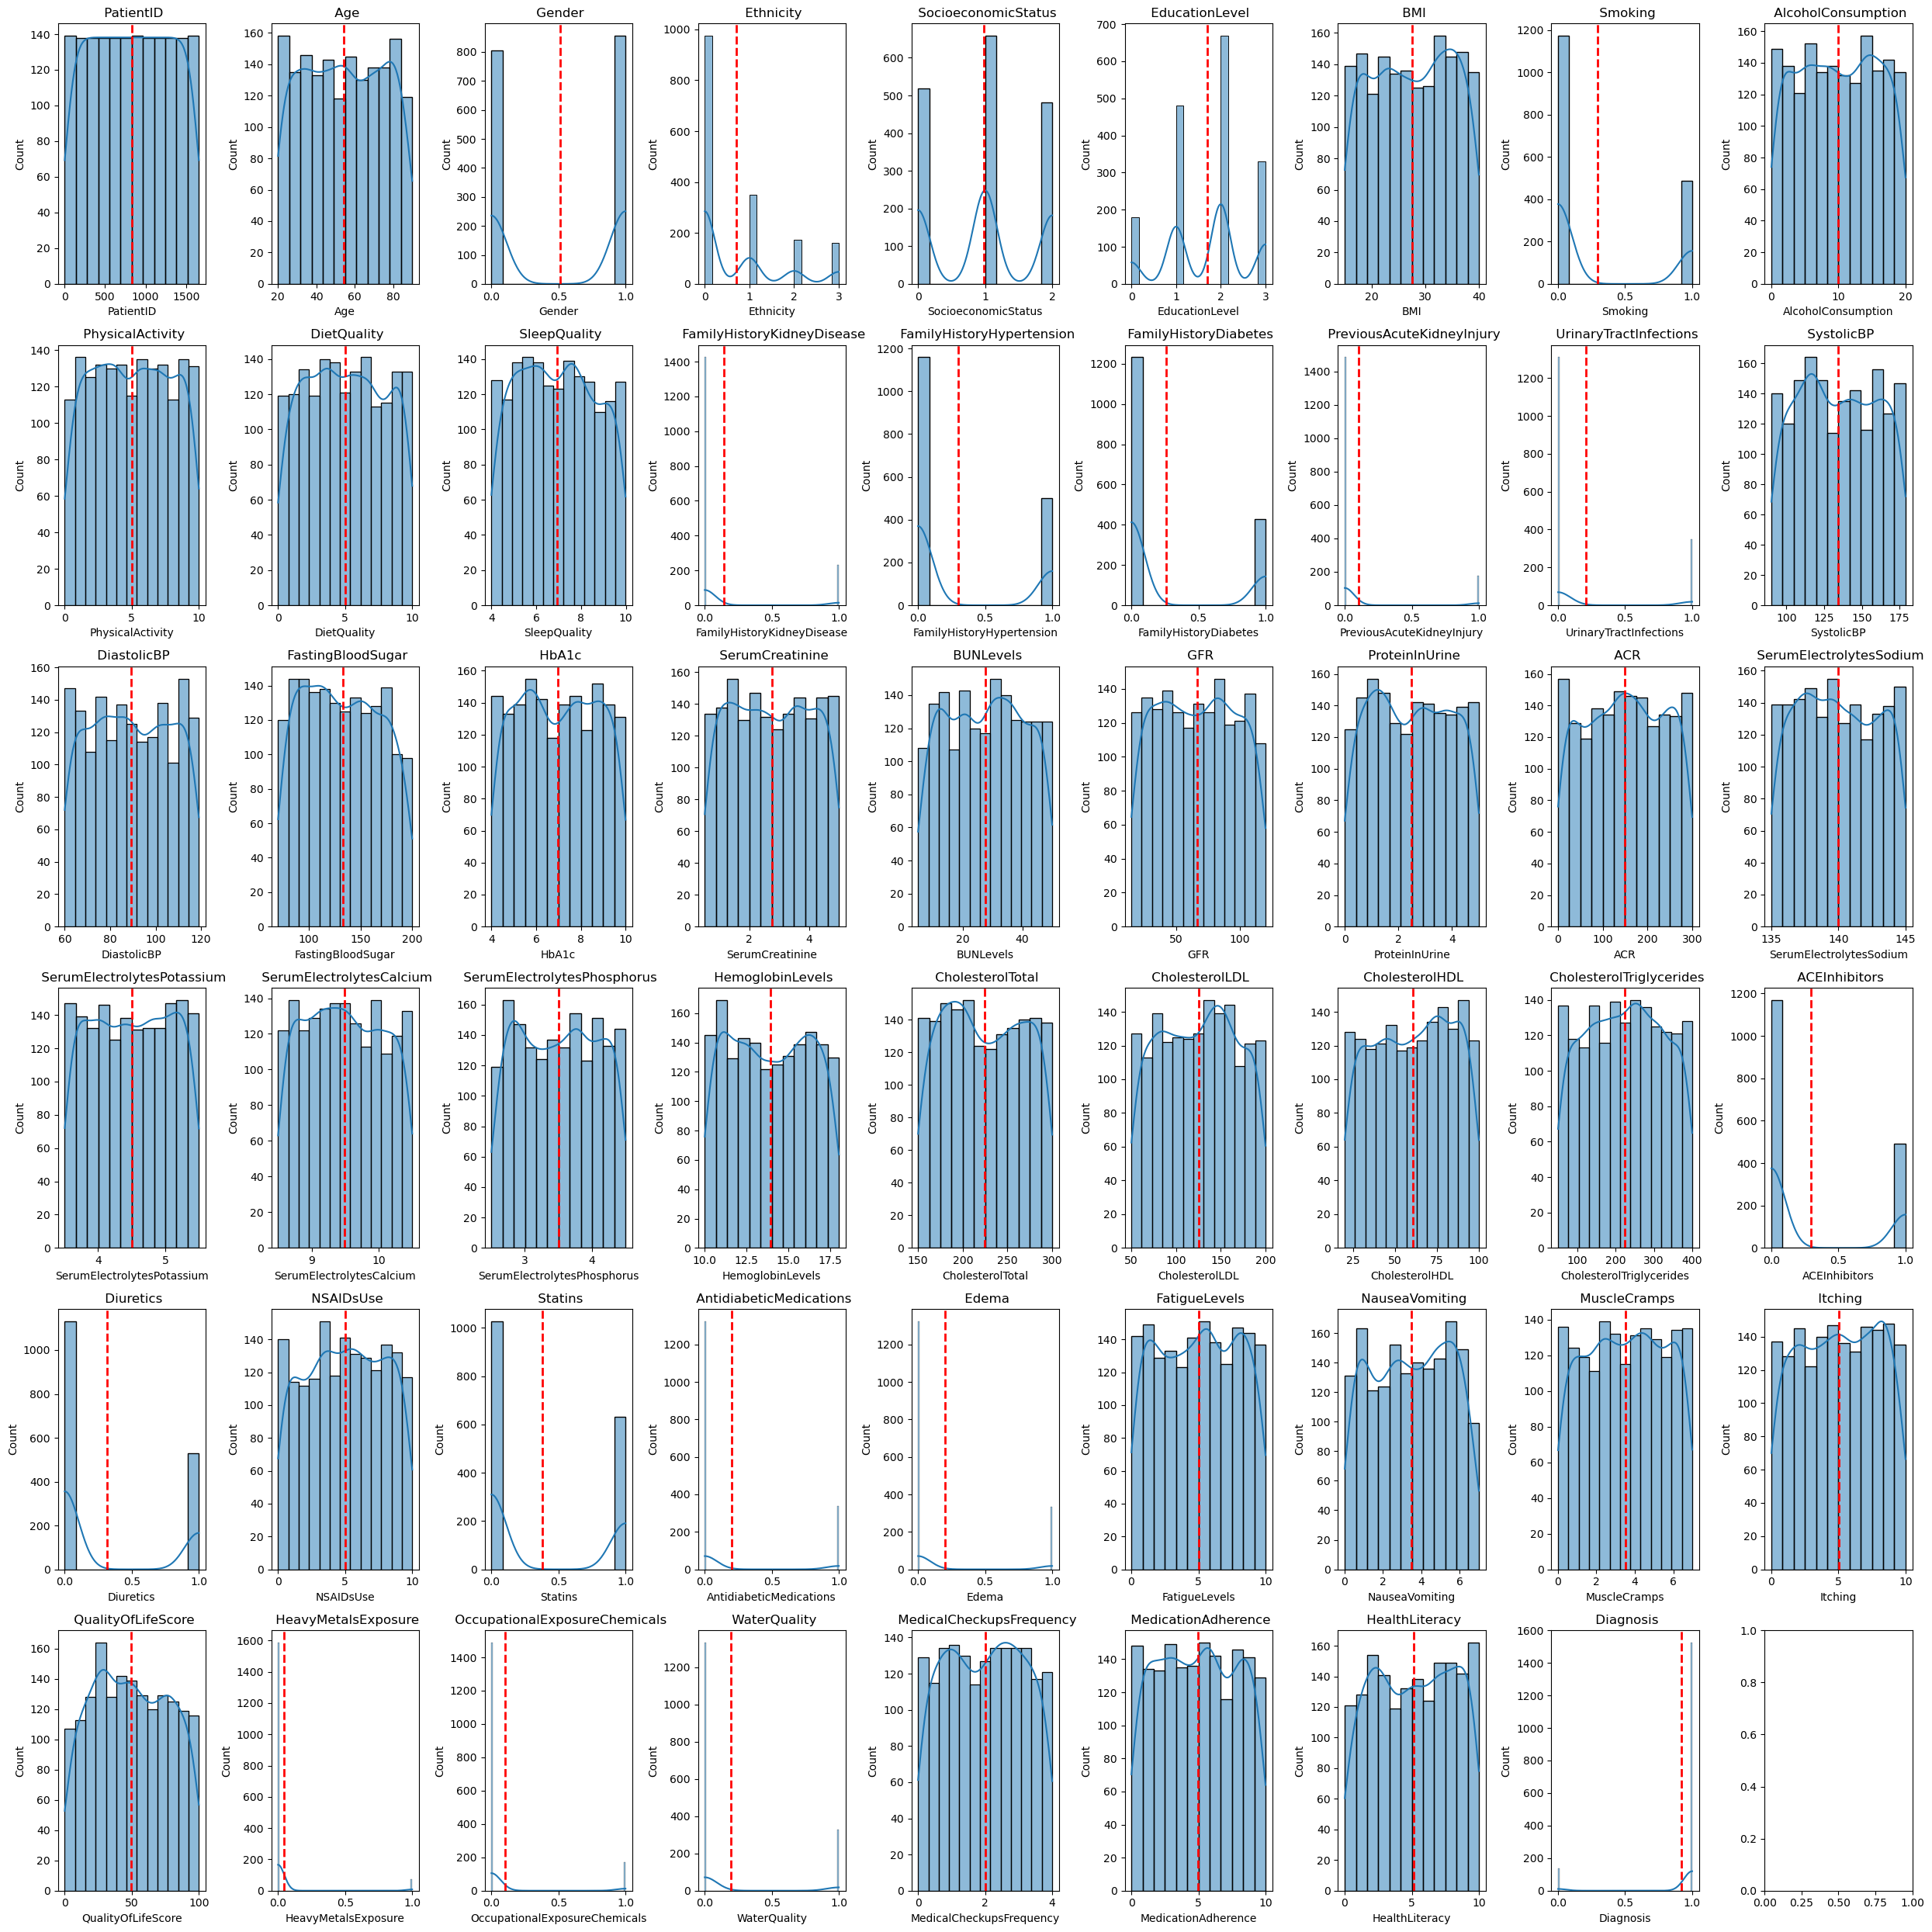

In [10]:
# Setting up a 6x9 grid of plots
fig, axes = plt.subplots(6, 9, figsize=(25, 25))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Plotting a KDE for each column in its respective subplot
for i, column in enumerate(ckd_df.columns):
    sns.histplot(ckd_df[column], ax=axes[i], kde=True)
    axes[i].set_title(f' {column}')

    #Add vertical line for mean
    mean_val = ckd_df[column].mean()
    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2)



#  Adjust layout so plots don’t overlap
plt.tight_layout()
plt.show()

##### Which biomaker diagnosed CKD better between GFR, BUN, and Protein in urine?

<Axes: xlabel='GFR', ylabel='Density'>

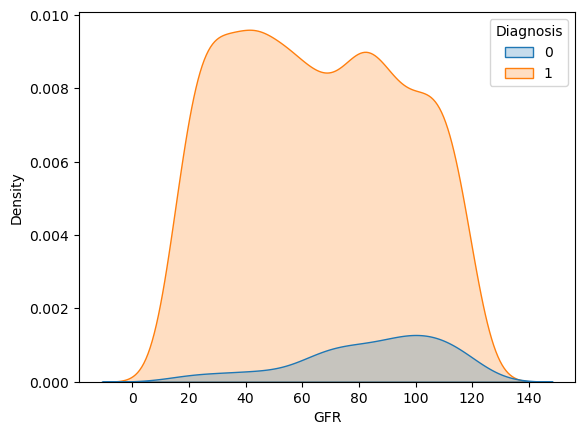

In [11]:
#Create a KDE plot of the GFR column using Diagnosis as hue.
sns.kdeplot(data = ckd_df, x = 'GFR', hue= 'Diagnosis', fill=True)

<Axes: xlabel='BUNLevels', ylabel='Density'>

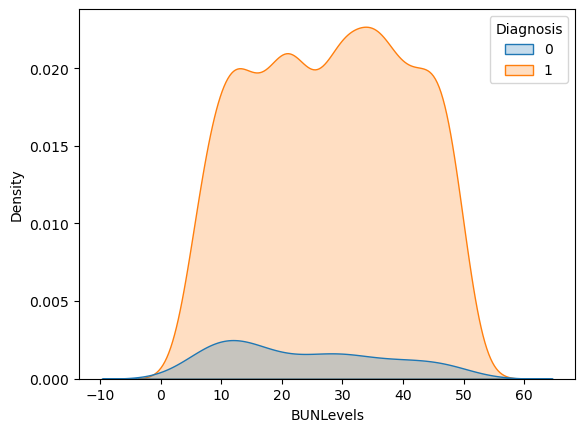

In [12]:
#Create a KDE plot of the BUN column using Diagnosis as hue.
sns.kdeplot(data = ckd_df, x = 'BUNLevels', hue= 'Diagnosis', fill=True)

<Axes: xlabel='ProteinInUrine', ylabel='Density'>

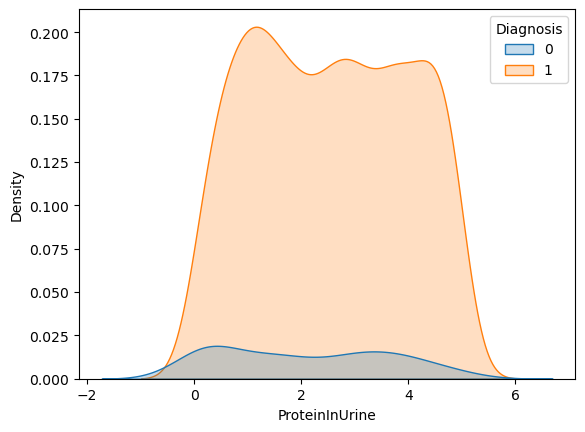

In [13]:
#Create a KDE plot of the ProteinInUrine column using Diagnosis as hue.
sns.kdeplot(data = ckd_df, x = 'ProteinInUrine', hue= 'Diagnosis', fill=True)

##### How many times does a patient with abnormal biomaker have negative CKD and vice versa?

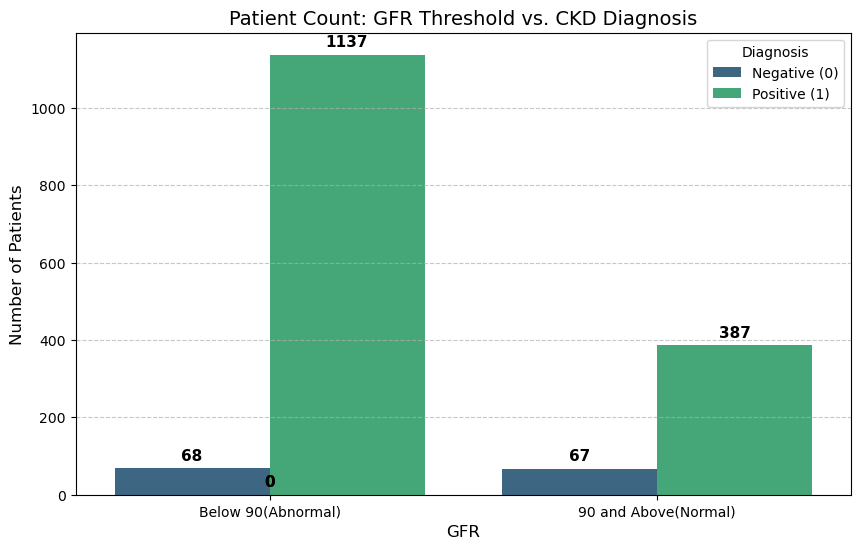

Number of patients with GFR < 90 and CKD Positive: 1137


In [14]:
# 1. Create a category for GFR threshold
ckd_df['GFR_Status'] = ckd_df['GFR'].apply(lambda x: 'Below 90(Abnormal)' if x < 90 else '90 and Above(Normal)')

# 2. Plot the counts
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=ckd_df, x='GFR_Status', hue='Diagnosis', palette='viridis')
# 3. Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Patient Count: GFR Threshold vs. CKD Diagnosis', fontsize=14)
plt.xlabel('GFR', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis', labels=['Negative (0)', 'Positive (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Print the specific count
target_count = len(ckd_df[(ckd_df['GFR'] < 90) & (ckd_df['Diagnosis'] == 1)])
print(f"Number of patients with GFR < 90 and CKD Positive: {target_count}")

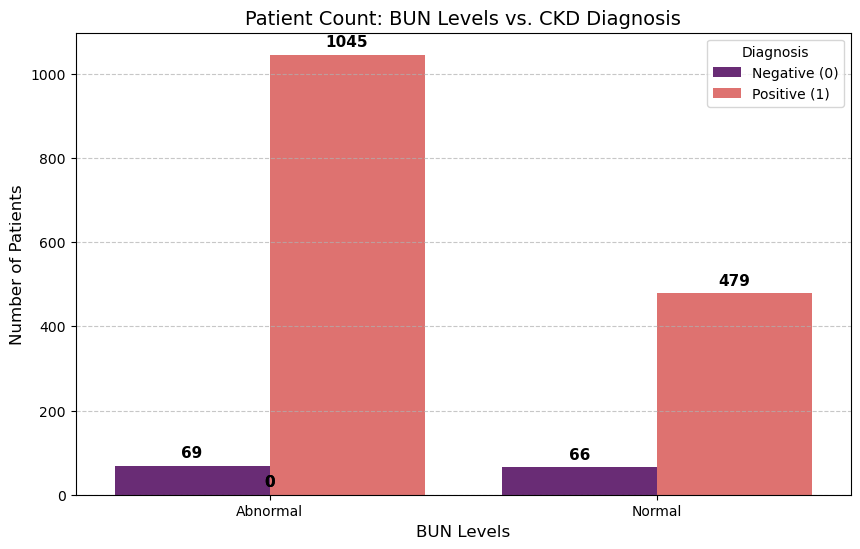

In [15]:
# Number normal vs abnormal BUN Levels
# 1. Categorize BUN Levels: 0-20 is Normal, >20 is Abnormal
ckd_df['BUN_Status'] = ckd_df['BUNLevels'].apply(lambda x: 'Abnormal' if x > 20 else 'Normal')

# 2. Plot the counts
plt.figure(figsize=(10, 6))
bx = sns.countplot(data=ckd_df, x='BUN_Status', hue='Diagnosis', palette='magma')

# 3. Add count labels on top of the bars
for p in bx.patches:
    bx.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')
plt.title('Patient Count: BUN Levels vs. CKD Diagnosis', fontsize=14)
plt.xlabel('BUN Levels', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis', labels=['Negative (0)', 'Positive (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

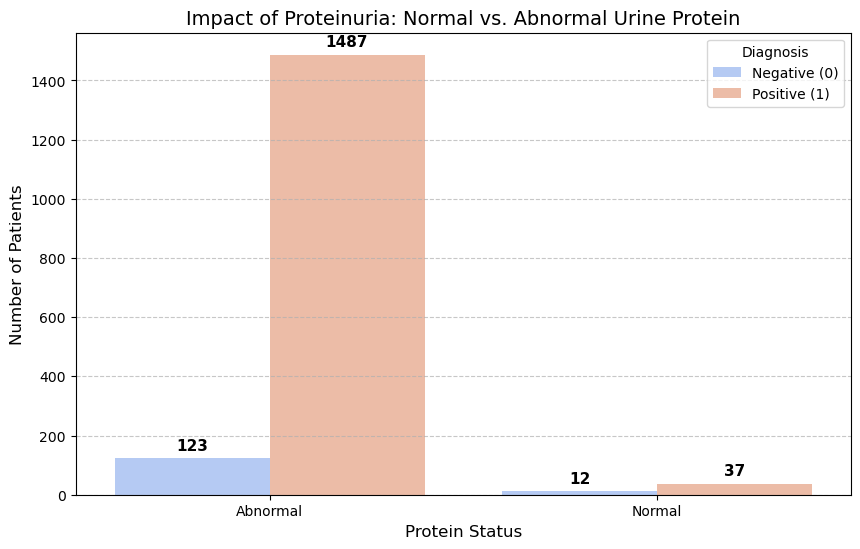

Number of patients with Abnormal Protein and CKD Positive: 1610


In [16]:
# Number normal vs abnormal protein in urine 
# 1. Categorize Protein: 0 is Normal, >0.15 is Abnormal
ckd_df['Protein_Status'] = ckd_df['ProteinInUrine'].apply(lambda x: 'Abnormal' if x > 0.15 else 'Normal')

# 2. Plot the counts
plt.figure(figsize=(10, 6))
# Using 'coolwarm' palette: yellow for normal, red for warning/abnormal
cx = sns.countplot(data=ckd_df, x='Protein_Status', hue='Diagnosis', palette='coolwarm', order=['Abnormal', 'Normal'])

# 3. Add count labels on top of the bars
for p in cx.patches:
    if p.get_height() > 0:
        cx.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Impact of Proteinuria: Normal vs. Abnormal Urine Protein', fontsize=14)
plt.xlabel('Protein Status', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis', labels=['Negative (0)', 'Positive (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Extract specific count for your report
protein_ckd_count = len(ckd_df[(ckd_df['ProteinInUrine'] > 0.15)])
print(f"Number of patients with Abnormal Protein and CKD Positive: {protein_ckd_count}")

##### A lot of patients in the dataset has Chronic kidney disease as well as damaged kidneys, as shown by the Impart of proteinuria plot. Most of the patient with CKD positive has abnormal urine protein level.


#### 🩺 Why GFR is the "Gold Standard" Over BUN and Protein in Urine when preventing Chronic Kidney Disease

In the diagnosis and staging of Chronic Kidney Disease (CKD), clinical practitioners and data scientists prioritize the **Glomerular Filtration Rate (GFR)**. While **Blood Urea Nitrogen (BUN)** and **Proteinuria** (protein in urine) provide valuable context, GFR remains the definitive metric for functional assessment.

---

##### 1. Functional Capacity vs. Secondary Indicators

* **GFR (The Filter Rate):** GFR measures exactly how many milliliters of blood the **glomeruli** (the kidney's filtering units) clear per minute. It represents the kidney's actual "output" and functional health.
* **BUN (The Waste Level):** BUN measures urea nitrogen, a byproduct of protein breakdown. It is an indirect indicator; high BUN means waste is accumulating, but it doesn't tell you *why* the filtration has slowed down.
* **Protein in Urine (The Filter Integrity):** Proteinuria indicates that the "mesh" of the kidney filter is damaged, allowing large molecules to leak through. While a critical sign of damage, it doesn't quantify the remaining filtering capacity.



---

##### 2. Sensitivity and Early Detection

* **GFR is Proactive:** GFR can detect "Early-Stage Kidney Disease" (Stage 2: 60–89) before symptoms appear. It allows for the five-stage classification system (Stage 1–5) used globally.
* **BUN is Reactive:** BUN levels often remain within the "normal" range until kidney function has dropped by **more than 50%**. By the time BUN spikes, the disease is usually advanced.
* **Protein is Inconsistent:** Not all forms of kidney disease cause significant protein leakage in the early stages. Relying solely on protein might miss "non-proteinuric" CKD cases.



---

##### 3. Specificity and "Noise" in the Data

In Data Science terms, GFR has a higher **Signal-to-Noise Ratio** than BUN or Protein in urine:

| Marker | Specificity to Kidney Health | External Factors (Noise) |
| :--- | :--- | :--- |
| **GFR** | **Very High** | Age and gender (accounted for in eGFR equations). |
| **BUN** | **Moderate** | Affected by high-protein diets, dehydration, steroids, and heart failure. |
| **Protein in urine** | **High** | Can be temporarily elevated by intense exercise, fever, or dehydration. |


In [17]:
# subset the data for patients with GFR 90 and above (Normal), positive diagnosis.
subset_ckd = ckd_df[(ckd_df['GFR'] >= 90) & (ckd_df['Diagnosis'] == 1)].copy()
# Display the first few rows of the subset
subset_ckd.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,GFR_Status,BUN_Status,Protein_Status
11,12,21,1,2,0,3,16.799520,1,11.460559,7.286423,...,0,0,1,3.261265,8.676258,9.222056,1,90 and Above(Normal),Normal,Abnormal
12,13,83,1,0,0,2,21.417015,1,0.475534,6.457103,...,0,0,0,3.482016,3.042926,1.964351,1,90 and Above(Normal),Abnormal,Abnormal
31,32,70,0,2,1,0,35.335172,0,5.125863,3.077928,...,0,0,0,3.694703,4.551414,4.245921,1,90 and Above(Normal),Abnormal,Abnormal
45,46,27,0,0,1,1,39.014213,0,10.818847,0.123883,...,0,0,0,1.206625,1.072096,4.531967,1,90 and Above(Normal),Abnormal,Abnormal
47,48,54,1,0,2,0,27.727046,0,14.612738,4.604268,...,0,0,1,0.737679,3.141972,4.523302,1,90 and Above(Normal),Normal,Abnormal


##### Could poor water quality cause CKD in normal GFR

C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\335735668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=water_quality_counts.index, y=water_quality_counts.values, palette='viridis')


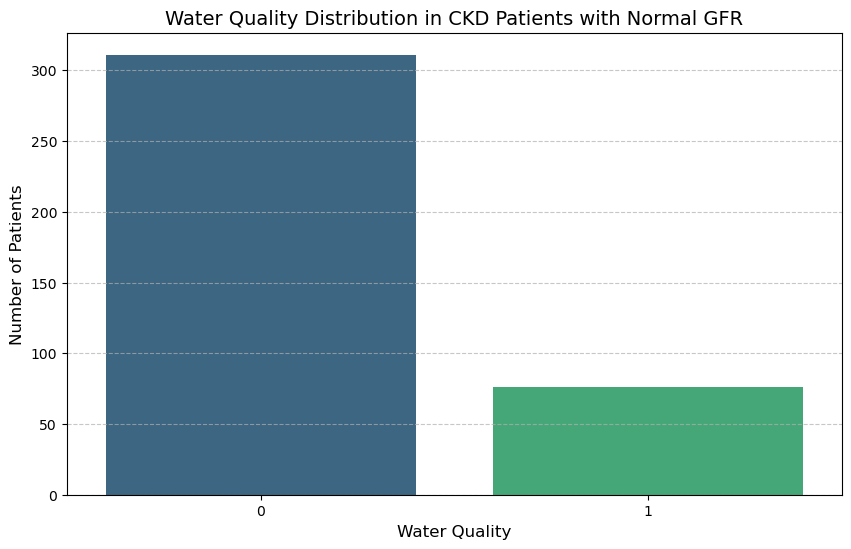

In [18]:
# Visualize count of water quality in the subset
water_quality_counts = subset_ckd['WaterQuality'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=water_quality_counts.index, y=water_quality_counts.values, palette='viridis')
plt.title('Water Quality Distribution in CKD Patients with Normal GFR', fontsize=14)
plt.xlabel('Water Quality', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\3906248981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=water_quality_counts_full.index, y=water_quality_counts_full.values, palette='viridis')


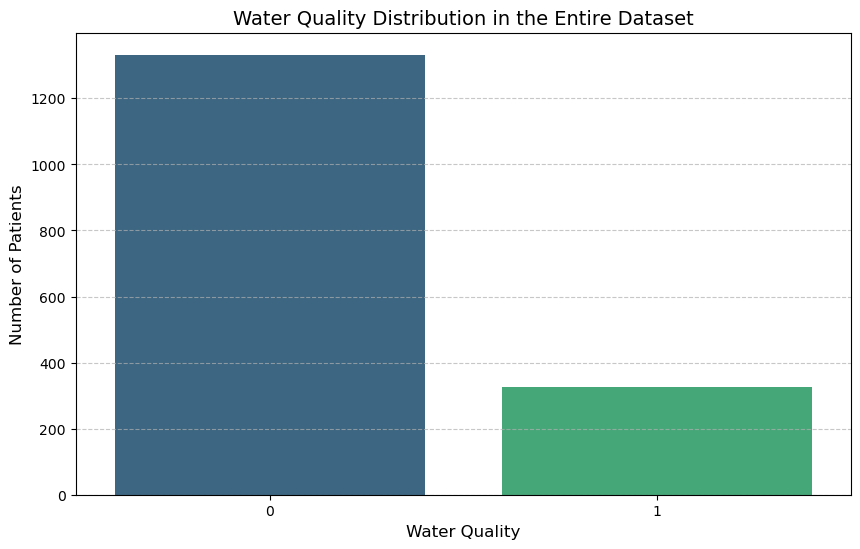

In [19]:
# water quality in the whole dataset
water_quality_counts_full = ckd_df['WaterQuality'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=water_quality_counts_full.index, y=water_quality_counts_full.values, palette='viridis')
plt.title('Water Quality Distribution in the Entire Dataset', fontsize=14)
plt.xlabel('Water Quality', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Water quality does not look like the cause


C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\3973967738.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.barplot(x=['Normal Protein', 'Abnormal Protein', 'Normal BUN', 'Abnormal BUN'],


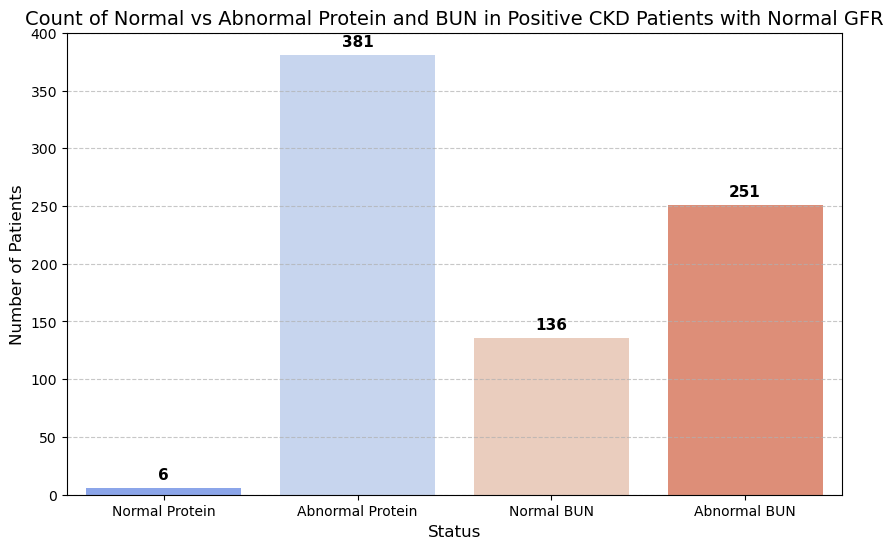

In [20]:
# A box plot to visualize the number patient with normal and abnormal protein in urine and BUN in the GfR < 90 and CKD Positive subset
count_norm_protein = len(subset_ckd[(subset_ckd['ProteinInUrine'] <= 0.15)])
count_abnorm_protein = len(subset_ckd[(subset_ckd['ProteinInUrine'] > 0.15)])
count_norm_bun = len(subset_ckd[(subset_ckd['BUNLevels'] <= 20)])
count_abnorm_bun = len(subset_ckd[(subset_ckd['BUNLevels'] > 20)])
plt.figure(figsize=(10, 6))

# Bar plot 
bx = sns.barplot(x=['Normal Protein', 'Abnormal Protein', 'Normal BUN', 'Abnormal BUN'], 
            y=[count_norm_protein, count_abnorm_protein, count_norm_bun, count_abnorm_bun], 
            palette='coolwarm', order=['Normal Protein', 'Abnormal Protein', 'Normal BUN', 'Abnormal BUN'])

# Add count labels on top of the bars
for p in bx.patches:
    if p.get_height() > 0:
        bx.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Count of Normal vs Abnormal Protein and BUN in Positive CKD Patients with Normal GFR', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




In [21]:
# Subset for Normal Protein in Urine in the Normal GFR and CKD Positive subset
subset_normal_protein = subset_ckd[subset_ckd['ProteinInUrine'] <= 0.15].copy()
subset_normal_protein

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,GFR_Status,BUN_Status,Protein_Status
191,192,52,0,1,1,2,21.240618,0,18.943384,7.974179,...,0,0,0,3.836632,9.196799,7.616870,1,90 and Above(Normal),Abnormal,Normal
198,199,42,0,0,0,3,32.334548,0,15.531818,7.566918,...,0,0,0,2.487919,9.992345,5.111292,1,90 and Above(Normal),Abnormal,Normal
386,387,38,1,0,2,1,38.237643,0,10.356906,9.242168,...,0,0,0,0.350833,3.904889,7.135446,1,90 and Above(Normal),Abnormal,Normal
522,523,51,1,0,1,2,29.666158,0,18.802438,6.006673,...,0,0,0,1.239666,9.295237,1.890462,1,90 and Above(Normal),Normal,Normal
532,533,66,1,0,1,1,38.239577,0,1.685844,7.442217,...,0,0,0,0.811343,8.268012,3.706680,1,90 and Above(Normal),Abnormal,Normal
902,903,20,0,0,1,2,33.943374,1,7.938637,7.258531,...,0,0,1,1.003131,7.842796,9.130213,1,90 and Above(Normal),Abnormal,Normal


C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\2028567579.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.barplot(x=['Normal BUN', 'Abnormal BUN'],


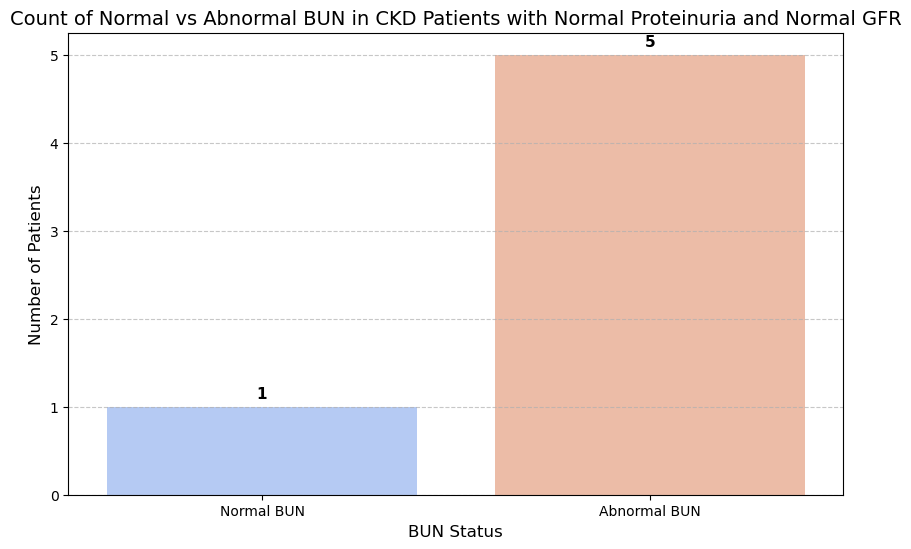

In [22]:
# Count BUN status in the normal protein subset
count_norm_bun_normal_protein = len(subset_normal_protein[subset_normal_protein['BUNLevels'] <= 20])
count_abnorm_bun_normal_protein = len(subset_normal_protein[subset_normal_protein['BUNLevels'] > 20])
plt.figure(figsize=(10, 6))
# Bar plot
bx = sns.barplot(x=['Normal BUN', 'Abnormal BUN'], 
            y=[count_norm_bun_normal_protein, count_abnorm_bun_normal_protein], 
            palette='coolwarm', order=['Normal BUN', 'Abnormal BUN'])
# Add count labels on top of the bars
for p in bx.patches:
    if p.get_height() > 0:
        bx.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')
plt.title('Count of Normal vs Abnormal BUN in CKD Patients with Normal Proteinuria and Normal GFR', fontsize=14)
plt.xlabel('BUN Status', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
# Subset normal BUN in the normal protein subset
subset_normal_bun_normal_protein = subset_normal_protein[subset_normal_protein['BUNLevels'] <= 20].copy()
subset_normal_bun_normal_protein

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,GFR_Status,BUN_Status,Protein_Status
522,523,51,1,0,1,2,29.666158,0,18.802438,6.006673,...,0,0,0,1.239666,9.295237,1.890462,1,90 and Above(Normal),Normal,Normal


In [24]:
# Transpose the BUN subset for better visualization
subset_normal_bun_normal_protein_transposed = subset_normal_bun_normal_protein.transpose()
subset_normal_bun_normal_protein_transposed

,522
PatientID,523
Age,51
Gender,1
Ethnicity,0
SocioeconomicStatus,1
EducationLevel,2
BMI,29.666158
Smoking,0
AlcoholConsumption,18.802438
PhysicalActivity,6.006673


### **The Diagnostic Anomalies of Chronic Kidney Disease**

This analysis has highlighted a critical truth in renal medicine: numbers like GFR (Glomerular Filtration Rate) are essential, but they don't always tell the whole story. By examining this dataset of 1,659 patients, we’ve uncovered how the "silent" nature of CKD can hide behind seemingly healthy lab results.

#### **The GFR Paradox: Normal Numbers, Positive Diagnosis**
A significant finding in this notebook was the identification of patients who maintain a "Normal" GFR (90+ mL/min), yet are still officially diagnosed with CKD. In a clinical setting, this is often due to **Proteinuria**. Even when the kidney is still filtering blood at a high volume, the presence of protein in the urine indicates that the physical structure of the kidney’s filters is already leaking. This proves that relying solely on filtration rates can be dangerous; early intervention must happen the moment the "sieve" begins to fail, not just when the flow slows down.



#### **The Ultimate Outlier: The "Healthy" CKD Patient**
Perhaps the most intriguing part of this study was the discovery of **exactly one patient** who presented with entirely normal biomarkers—normal GFR, normal BUN, and no protein in the urine—yet still received a CKD diagnosis. 
* **In a Clinical Context:** This rare case represents the complexity of the disease, where factors like family history, heavy metal exposure, or chronic inflammation might lead a doctor to a diagnosis before the lab work catches up.
* **In a Data Context:** This outlier serves as a reminder that synthetic datasets can contain "noise," but it also challenges us to think about the patients who fall through the cracks of standard testing.

#### **Summary for the Project**
This project successfully demonstrates that CKD is not a one-size-fits-all condition. While most patients follow the traditional path of rising BUN and falling GFR, the existence of patients with normal biomarkers highlights the need for **comprehensive medical screening**. By analyzing these specific anomalies, we have moved beyond basic statistics to understand the nuanced logic required to diagnose and treat this global health crisis effectively.



In [25]:
ckd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [26]:
# Correllation between all the columns
ckd_df = ckd_df.drop(columns=['GFR_Status', 'BUN_Status', 'Protein_Status']) # Drop the categorical columns before correlation
corr = ckd_df.corr()
corr

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
PatientID,1.000000,0.001166,-0.023822,-0.016970,0.025289,0.029565,-0.036264,-0.005863,0.029087,-0.003768,...,0.003806,-0.042814,-0.011147,-0.028480,0.002591,0.028288,-0.018654,0.001955,0.004524,-0.171405
Age,0.001166,1.000000,-0.037765,-0.006307,0.001448,0.008947,-0.033202,0.020215,-0.006030,0.003485,...,0.001318,0.005683,-0.022676,0.043746,-0.014711,-0.038522,-0.015165,0.043168,0.010920,0.000919
Gender,-0.023822,-0.037765,1.000000,0.025707,0.004767,-0.022095,-0.023381,0.004054,-0.020473,0.014840,...,-0.028158,0.001424,0.015554,0.013984,-0.000509,0.019628,0.020156,-0.026356,-0.014644,0.042239
Ethnicity,-0.016970,-0.006307,0.025707,1.000000,-0.047051,0.039696,-0.008506,0.019127,-0.033574,-0.057811,...,-0.004542,-0.031039,0.010930,0.008654,0.010036,-0.036629,0.023191,0.007489,0.012971,0.007199
SocioeconomicStatus,0.025289,0.001448,0.004767,-0.047051,1.000000,-0.003711,-0.030242,0.021900,0.010864,-0.000259,...,-0.026640,-0.003762,-0.007924,0.036443,-0.013242,-0.005283,0.002820,0.009689,-0.022453,-0.034104
EducationLevel,0.029565,0.008947,-0.022095,0.039696,-0.003711,1.000000,-0.016669,0.003070,0.046814,-0.003066,...,0.018786,0.004209,-0.016503,-0.047143,0.020611,-0.029415,0.022940,-0.005434,-0.000944,-0.037343
BMI,-0.036264,-0.033202,-0.023381,-0.008506,-0.030242,-0.016669,1.000000,-0.000968,-0.067239,0.003528,...,-0.030355,0.023998,-0.046046,-0.032956,0.008763,0.006205,0.002934,0.020329,-0.015661,0.055222
Smoking,-0.005863,0.020215,0.004054,0.019127,0.021900,0.003070,-0.000968,1.000000,0.032707,0.006153,...,0.057832,-0.006464,0.017025,-0.015402,-0.009121,0.000686,0.033114,-0.043634,0.028563,0.026875
AlcoholConsumption,0.029087,-0.006030,-0.020473,-0.033574,0.010864,0.046814,-0.067239,0.032707,1.000000,0.056835,...,-0.008730,0.018152,0.000959,-0.026421,0.030144,0.027446,0.022099,0.011002,-0.012806,-0.006245
PhysicalActivity,-0.003768,0.003485,0.014840,-0.057811,-0.000259,-0.003066,0.003528,0.006153,0.056835,1.000000,...,0.035289,-0.011907,0.006563,-0.001012,0.001602,-0.003056,-0.017973,0.059385,0.007185,-0.021550


##### What is the relationship between Serum Creatinine level and GFR?

In [27]:
# Correllation between Serum Creatinine and GFR
corr_creatinine_gfr = ckd_df['SerumCreatinine'].corr(ckd_df['GFR'])
print(f"Correlation between Serum Creatinine and GFR: {corr_creatinine_gfr:.5f}")

Correlation between Serum Creatinine and GFR: -0.00343


C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\2901800559.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=ckd_df, x='SerumCreatinine', y='GFR', palette='Set1')


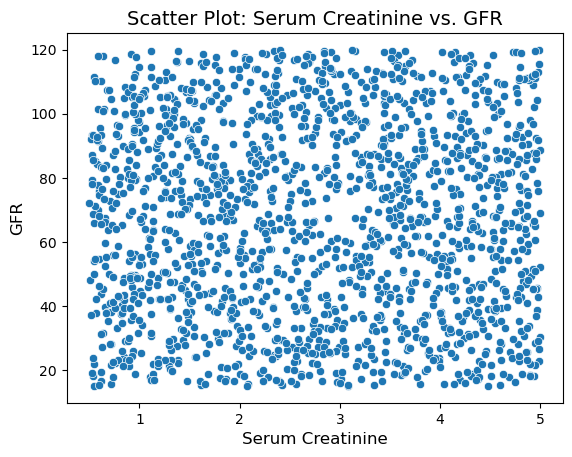

In [28]:
# Scatter plot between serum creatinine and GFR
sns.scatterplot(data=ckd_df, x='SerumCreatinine', y='GFR', palette='Set1')
plt.title('Scatter Plot: Serum Creatinine vs. GFR', fontsize=14)
plt.xlabel('Serum Creatinine', fontsize=12)
plt.ylabel('GFR', fontsize=12)
plt.show()

##### The above does not make sense clinically. Although it was not stated whether the GFR was measured or estimated in the dataset, it was still suppose to have a strong correlation with serum creatinine. This is one of the beautiful limitation of a synthetic dataset.

In [29]:
ckd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

##### What is the Relationship between Age and GFR?

In [30]:
# Corellation between Age and GFR
corr_age_gfr = ckd_df['Age'].corr(ckd_df['GFR'])
print(f"Correlation between Age and GFR: {corr_age_gfr:.5f}")

Correlation between Age and GFR: 0.04583


C:\Users\rosea\AppData\Local\Temp\ipykernel_3440\2688795703.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=ckd_df, x='Age', y='GFR', palette='Set2')


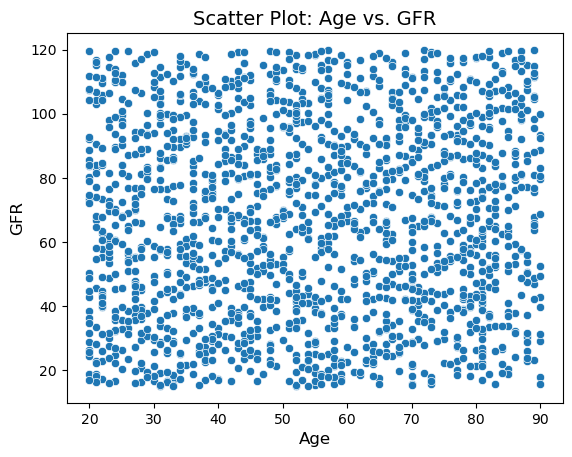

In [31]:
# Scatter plot between Age and GFR
sns.scatterplot(data=ckd_df, x='Age', y='GFR', palette='Set2')
plt.title('Scatter Plot: Age vs. GFR', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('GFR', fontsize=12)
plt.show()

##### What is the relationship between Gender and serum creatinine?

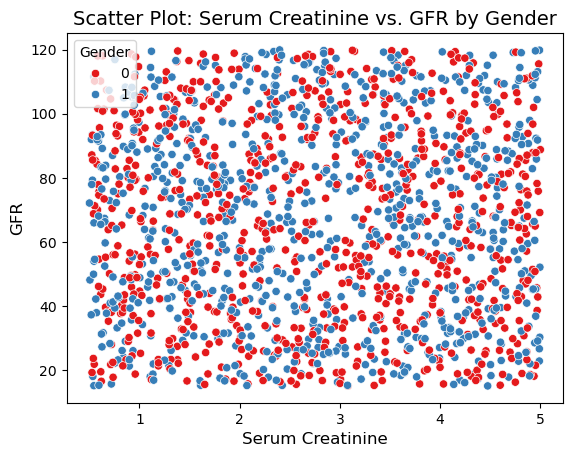

In [32]:
# Scatter plot between serum creatinine and gender
sns.scatterplot(data=ckd_df, x='SerumCreatinine', y='GFR', hue='Gender', palette='Set1')
plt.title('Scatter Plot: Serum Creatinine vs. GFR by Gender', fontsize=14)
plt.xlabel('Serum Creatinine', fontsize=12)
plt.ylabel('GFR', fontsize=12)
plt.show()


##### How does demographics affect the Biomakers ?

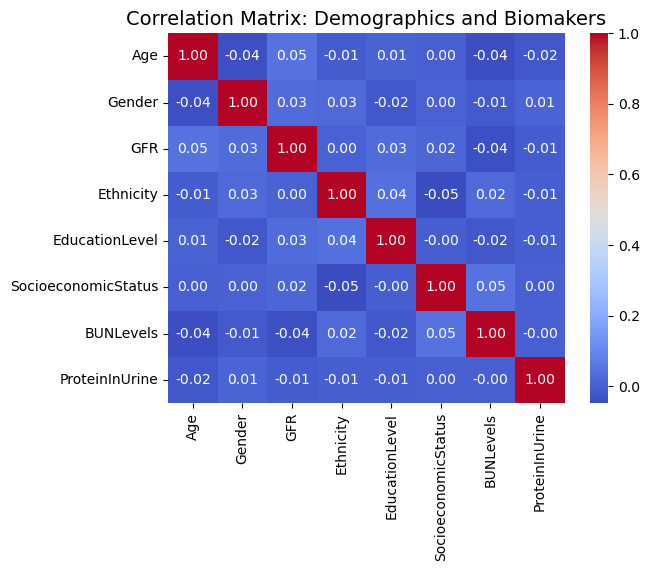

In [33]:
# Selecting relevant demographic and GFR columns for further analysis
ckd_demographics_gfr = ckd_df[['Age', 'Gender', 'GFR','Ethnicity', 'EducationLevel', 'SocioeconomicStatus','BUNLevels', 'ProteinInUrine']]

# Correlation matrix for demographics and GFR
corr_demographics_gfr = ckd_demographics_gfr.corr()
sns.heatmap(corr_demographics_gfr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Demographics and Biomakers', fontsize=14)
plt.show()

In [34]:
ckd_df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus',
       'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension',
       'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury',
       'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
       'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting',
       'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure',
       'OccupationalExposureChemicals', 'WaterQu

##### How does Lifestyle Factor affect the Biomakers?

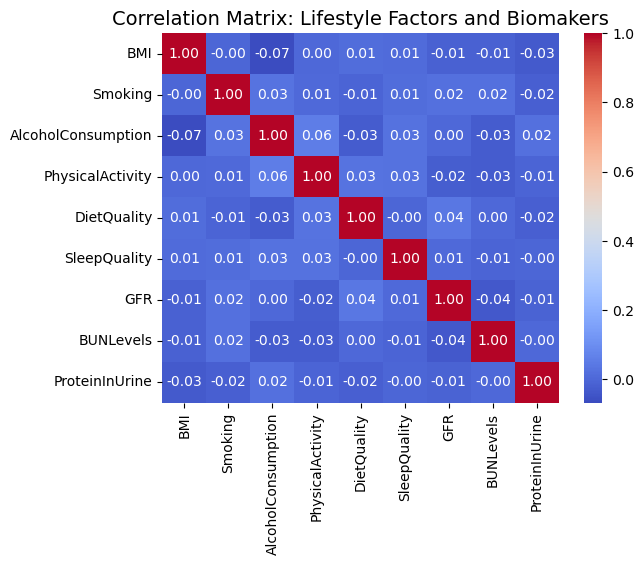

In [35]:
# Selecting relevant Lifestyle Factors and GFR columns for further analysis
ckd_lifestyle_biomarkers = ckd_df[['BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality', 'GFR','BUNLevels', 'ProteinInUrine']]

# Correlation matrix for demographics and biomakers
corr_lifestyle_biomarkers = ckd_lifestyle_biomarkers.corr()
sns.heatmap(corr_lifestyle_biomarkers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Lifestyle Factors and Biomakers', fontsize=14)
plt.show()

##### How does Medical History affect Biomakers

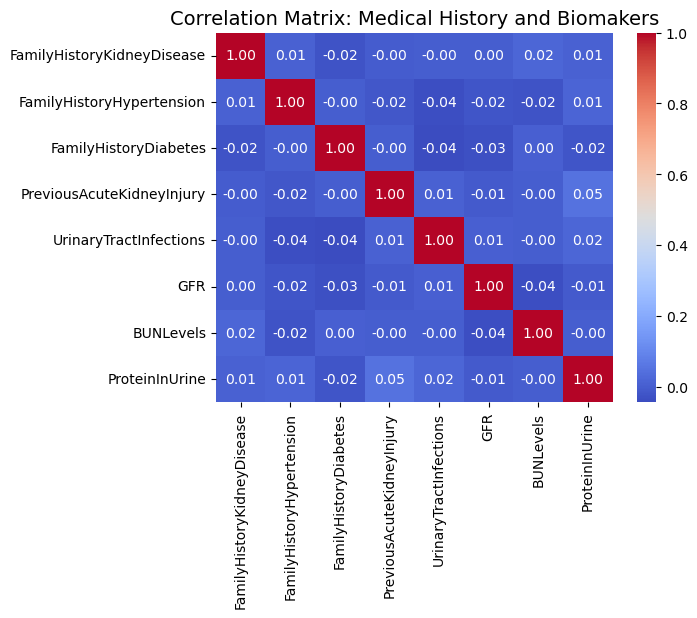

In [36]:
# Selecting relevant Medical History and biomakers columns for further analysis
ckd_medical_history_biomarkers = ckd_df[['FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension',
       'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury',
       'UrinaryTractInfections', 'GFR','BUNLevels', 'ProteinInUrine']]

# Correlation matrix for demographics and biomakers
corr_medical_history_biomarkers = ckd_medical_history_biomarkers.corr()
sns.heatmap(corr_medical_history_biomarkers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Medical History and Biomakers', fontsize=14)
plt.show()

##### Is there any correlation between other clinical measurements and Biomakers

In [37]:
# Selecting other relevant Clinical Measurements and biomarkers columns for further analysis
ckd_clinical_biomarkers = ckd_df[['SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides']]

# Correlation of other clinical measurements and Biomakers
corr_clinical_biomarkers = ckd_clinical_biomarkers.corr()
corr_clinical_biomarkers = corr_clinical_biomarkers[['GFR','BUNLevels','ProteinInUrine']].sort_values(by=['GFR', 'BUNLevels', 'ProteinInUrine'], ascending=False)
print("Correlation of Clinical Measurements with Biomarkers:")
print(corr_clinical_biomarkers)

Correlation of Clinical Measurements with Biomarkers:
                                  GFR  BUNLevels  ProteinInUrine
GFR                          1.000000  -0.036221       -0.009442
SerumElectrolytesPotassium   0.020225   0.001759       -0.017865
SerumElectrolytesPhosphorus  0.018832  -0.009338       -0.044162
SerumElectrolytesSodium      0.011776  -0.013878       -0.024127
SystolicBP                   0.009462   0.021084       -0.012435
FastingBloodSugar            0.008208  -0.013031       -0.036826
CholesterolHDL               0.002722   0.012696        0.041872
CholesterolLDL               0.002333  -0.011274        0.026595
DiastolicBP                 -0.001276   0.006522       -0.002373
SerumCreatinine             -0.003434   0.022555       -0.037101
ACR                         -0.008342   0.011626       -0.014503
ProteinInUrine              -0.009442  -0.000365        1.000000
CholesterolTotal            -0.014407   0.015287        0.044105
HemoglobinLevels            -0.01916

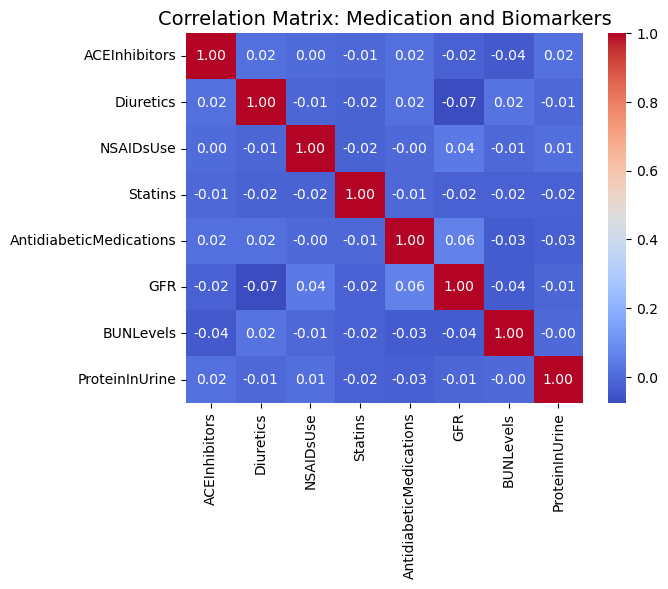

In [38]:
# Selecting relevant Medication and Biomakers columns for further analysis
ckd_medication_bmakers = ckd_df[['ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'GFR', 'BUNLevels', 'ProteinInUrine']]

# Correlation matrix for medication and biomarkers
corr_medication_bmakers = ckd_medication_bmakers.corr()
sns.heatmap(corr_medication_bmakers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Medication and Biomarkers', fontsize=14)
plt.show()

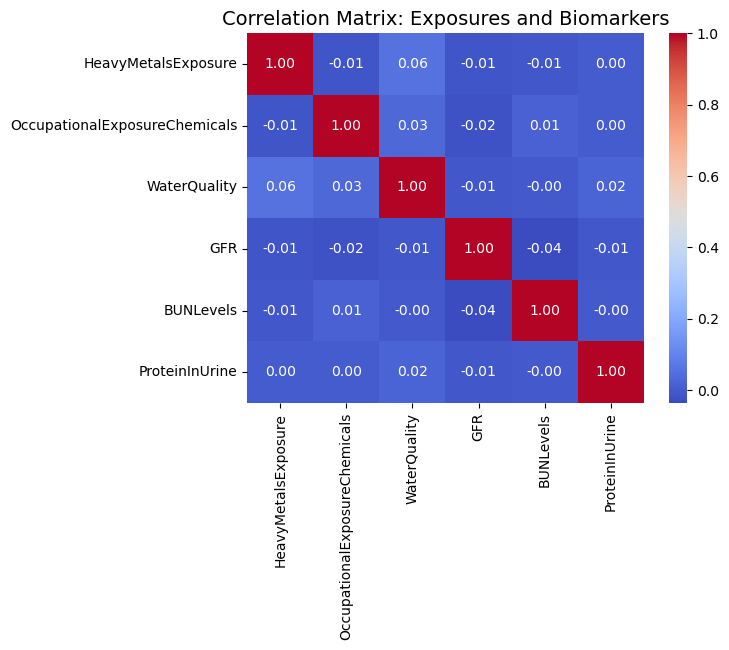

In [39]:
# Selecting relevant Exposures and Biomakers columns for further analysis
ckd_exposures_bmakers = ckd_df[['HeavyMetalsExposure',
       'OccupationalExposureChemicals', 'WaterQuality', 'GFR', 'BUNLevels', 'ProteinInUrine']]

# Correlation matrix for exposures and biomarkers
corr_exposures_bmakers = ckd_exposures_bmakers.corr()
sns.heatmap(corr_exposures_bmakers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Exposures and Biomarkers', fontsize=14)
plt.show()

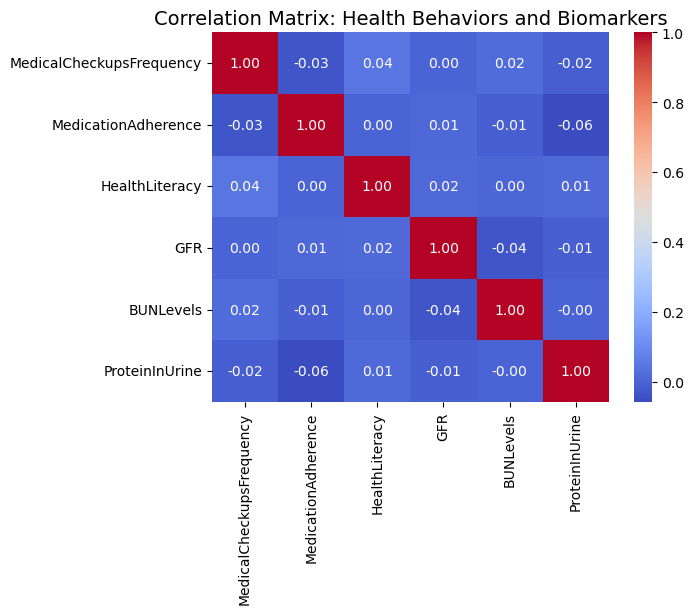

In [40]:
# Selecting Health behaviors and Biomakers columns for further analysis
ckd_behaviours_bmakers = ckd_df[['MedicalCheckupsFrequency', 'MedicationAdherence', 'HealthLiteracy', 'GFR', 'BUNLevels', 'ProteinInUrine']]

# Correlation matrix for health behaviors and biomarkers
corr_behaviours_bmakers = ckd_behaviours_bmakers.corr()
sns.heatmap(corr_behaviours_bmakers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Health Behaviors and Biomarkers', fontsize=14)
plt.show()

##### Synthetic data is beautifully funny. There is little 0r no correlation between any feature.


### **Final Reflections: What the Data Tells Us About CKD**

Completing this exploratory analysis has provided a clear window into the complexities of **Chronic Kidney Disease (CKD)**. While the data itself is synthetic and lacks the messy correlations often found in real-world clinical settings, the process of digging through these 1,659 patient records has highlighted exactly what healthcare providers look for when trying to save a patient’s kidney function.

#### **Beyond the Numbers: Key Insights**
* **The Silent Progressor:** One of the most striking takeaways was seeing how a patient can have a "Normal" GFR (the standard measure of kidney health) and yet still be diagnosed with CKD. This happens because of **Proteinuria**. It reminds us that protein leaking into the urine isn't just a symptom; it’s an active "driver" of damage that can be caught before the kidneys begin to fail significantly.
* **The Importance of Precision:** With 54 different variables—ranging from heavy metal exposure to health literacy—this project showed that a diagnosis is never based on a single data point. It is a puzzle where **BUN**, **Creatinine**, and **Lifestyle factors** must all be viewed together to see the full picture of a patient's health.



#### **What This Means for the Future**
Even though the statistical correlations were low due to the nature of the dataset, the **analytical workflow** is what matters most. We’ve built a roadmap here:
1.  **Identify** the early red flags (Proteinuria).
2.  **Monitor** the filtration efficiency (GFR).
3.  **Track** the buildup of waste products (BUN).

#### **Closing Thoughts**
This EDA was more than just a coding exercise; it was an exploration of a global health crisis that affects nearly 850 million people. By mastering how to visualize, and interpret these biomarkers, we are better equipped to handle real-world medical data. The ultimate goal remains the same: using data to move from reactive treatment to proactive prevention, ensuring that the "silent" stages of kidney disease are heard loud and clear.


This project successfully demonstrates that CKD is not a one-size-fits-all condition. While most patients follow the traditional path of rising BUN and falling GFR, the existence of patients with normal biomarkers highlights the need for **comprehensive medical screening**. By analyzing these specific anomalies, we have moved beyond basic statistics to understand the nuanced logic required to diagnose and treat this global health crisis effectively.